# 05. ML-Q 예측: Step3 방식 (개별 주식 분류 → 포트폴리오 Q)

**Step3_IndividualStocks의 회귀를 분류로 전환**

## 구조
```
Step3 monthly_panel.csv  (개별 주식 피처 + fwd_excess_ret_1m)
         ↓
  피처 정규화 (GKX 방식)
    - 주식 피처: 날짜별 횡단면 rank → [-1, 1]
    - 매크로 피처: rolling z-score
         ↓
  종목별 방향 분류 (XGBClassifier, walk-forward expanding)
    - 타겟: fwd_excess_ret_1m 방향 (up / neutral / down) 종목별
         ↓
  P 포트폴리오 수준으로 집계
    - portfolio_score = Σ P_i × (prob_up_i - prob_down_i)
    - portfolio_direction = sign(portfolio_score)
         ↓
  Q_conditional = 훈련 기간 내 해당 방향의 P_ret 평균
         ↓
  99_baseline.ipynb에서 Q 대체
```

## Step3와의 차이점
| | Step3 (기존) | 05_ML_Q (신규) |
|---|---|---|
| 타겟 | fwd_excess_ret_1m 연속값 (회귀) | 방향: up/neutral/down (분류) |
| 출력 | 종목별 예측 수익률 (BL에 직접 입력) | 포트폴리오 방향 → 조건부 Q |
| 피처 정규화 | GKX 횡단면 rank | 동일 |
| walk-forward | 연간 expanding window | 동일 |

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

PANEL_DATA = Path('data/monthly_panel_ml.csv')
OUTPUT_DIR = Path('outputs/05_ml_q')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PCT_GROUP    = 0.30
DIR_THR      = 0.005   # EDA 후 재검토 예정
MIN_TRAIN_YR = 3
START_PRED   = '2009'
RANDOM_SEED  = 42

# 개별 종목 피처 (횡단면 rank 정규화)
STOCK_FEATS = [
    'mom_1w', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
    'mom_12m_skip_1m', 'chmom',
    'vol_21d', 'vol_60d', 'vol_252d', 'beta_252d',
    'idiovol_21d', 'ivol_63d',
    'log_mcap',
    'high52w_ratio', 'low52w_ratio', 'maxret_21d',
    'ma_gap_20_60', 'rsi_14', 'bb_pct', 'intraday_range',
    'vol_surge', 'dollar_vol_21d', 'amihud_21d',
    'autocorr_21d',
    'sharpe_21d', 'sharpe_63d', 'sortino_63d',
    'ir_63d', 'skew_63d', 'kurt_63d', 'mdd_252d',
    'indmom',
    'is_Energy', 'is_Materials', 'is_Industrials',
    'is_Consumer_Discretionary', 'is_Consumer_Staples',
    'is_Health_Care', 'is_Financials', 'is_Information_Technology',
    'is_Communication_Services', 'is_Utilities', 'is_Real_Estate',
]

# 매크로 피처 (rolling z-score)
MACRO_FEATS = [
    'vix', 't10y2y', 'dxy', 'gold', 'wti_crude',
    'copper', 'silver', 'skew_idx',
    'icsa', 'sahm', 'cpi', 'unrate',
    'ff_mkt_rf', 'ff_smb', 'ff_hml',
    'ff_rmw', 'ff_cma', 'ff_mom_factor',
]

print('설정 완료')
print(f'STOCK_FEATS: {len(STOCK_FEATS)}개  |  MACRO_FEATS: {len(MACRO_FEATS)}개')
print(f'DIR_THR = +-{DIR_THR*100:.1f}%  |  PCT_GROUP = {PCT_GROUP:.0%}  |  MIN_TRAIN = {MIN_TRAIN_YR}년')

설정 완료
STOCK_FEATS: 44개  |  MACRO_FEATS: 18개
DIR_THR = +-0.5%  |  PCT_GROUP = 30%  |  MIN_TRAIN = 3년


In [9]:
# ── ML 패널 로드 ─────────────────────────────────────────────
# monthly_panel_ml.csv: (date, ticker) MultiIndex로 저장됨
# → date를 인덱스로, ticker를 컬럼으로 읽기
panel = pd.read_csv(PANEL_DATA, parse_dates=['date']).set_index('date')
panel = panel.sort_index()

print(f'ML 패널: {panel.shape}')
print(f'기간: {panel.index.min().date()} ~ {panel.index.max().date()}')
print(f'종목: {panel["ticker"].nunique()}개  |  날짜: {panel.index.nunique()}개')

# 가용 피처 필터링
STOCK_FEATS = [f for f in STOCK_FEATS if f in panel.columns]
MACRO_FEATS = [f for f in MACRO_FEATS if f in panel.columns]
print(f'\n주식 피처 사용 가능: {len(STOCK_FEATS)}개')
print(f'매크로 피처 사용 가능: {len(MACRO_FEATS)}개')

assert 'fwd_excess_ret_1m' in panel.columns, 'fwd_excess_ret_1m 컬럼 없음'
assert 'vol_21d' in panel.columns, 'vol_21d 컬럼 없음'
print(f'\nfwd_excess_ret_1m NaN: {panel["fwd_excess_ret_1m"].isna().mean():.1%}')
print(f'vol_21d NaN: {panel["vol_21d"].isna().mean():.1%}')

ML 패널: (108180, 69)
기간: 2004-01-31 ~ 2025-12-31
종목: 621개  |  날짜: 264개

주식 피처 사용 가능: 44개
매크로 피처 사용 가능: 18개

fwd_excess_ret_1m NaN: 0.0%
vol_21d NaN: 0.3%


P 수익률 계산 완료: 263개월
  평균  : 0.0034  (연 4.1%)
  std   : 0.0604
  >0 비율: 52.9%
  종목 수: 평균 410개


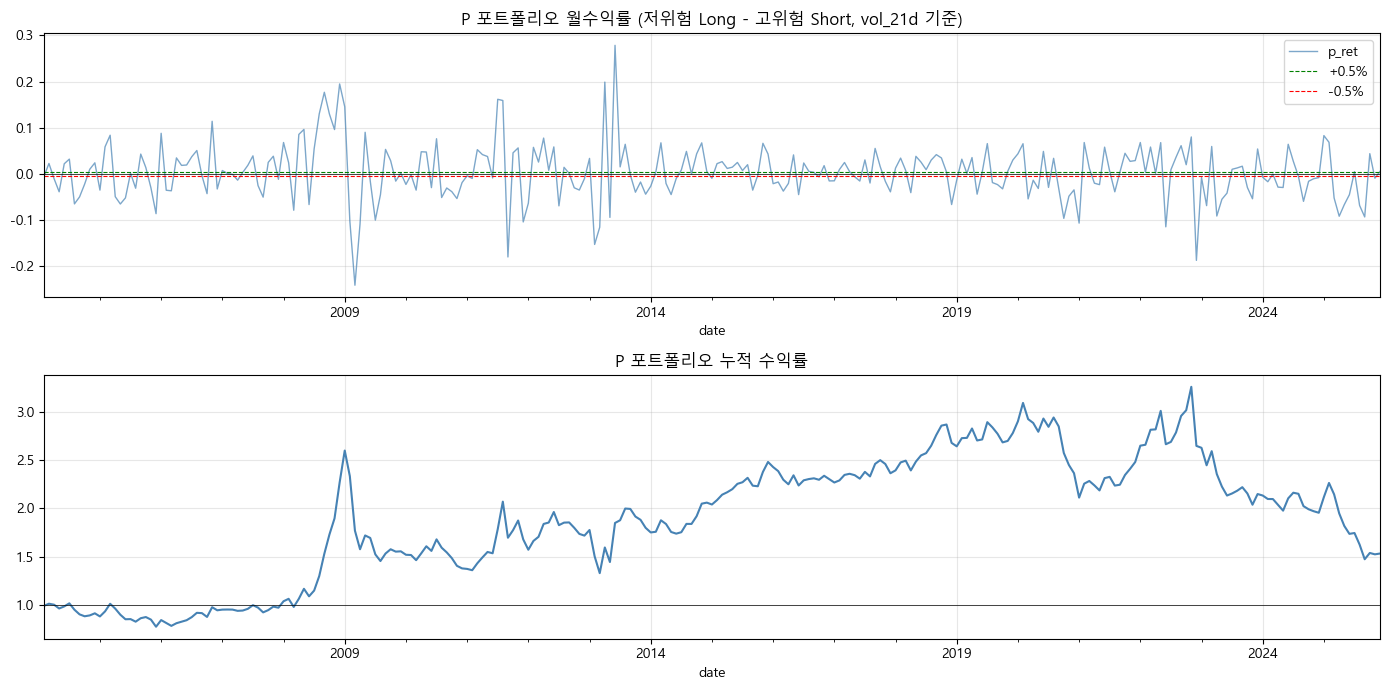

In [10]:
# ── P 포트폴리오 월별 수익률 계산 ──────────────────────────────
# P_t = vol_21d 하위 30% Long (시총가중) + 상위 30% Short (시총가중)
# → 99_baseline과 동일한 기준

p_records = []

for date, grp in panel.groupby(panel.index):
    grp_c = grp.dropna(subset=['vol_21d', 'log_mcap', 'fwd_excess_ret_1m']).reset_index(drop=True)
    if len(grp_c) < 30:
        continue

    n_g    = max(1, int(len(grp_c) * PCT_GROUP))
    sv     = grp_c['vol_21d'].sort_values()
    lo_idx = sv.index[:n_g]
    hi_idx = sv.index[-n_g:]

    cap_lo = np.exp(grp_c.loc[lo_idx, 'log_mcap'])
    cap_hi = np.exp(grp_c.loc[hi_idx, 'log_mcap'])
    w_lo   =  cap_lo / cap_lo.sum()
    w_hi   = -cap_hi / cap_hi.sum()

    p_ret_val = (w_lo @ grp_c.loc[lo_idx, 'fwd_excess_ret_1m'].fillna(0) +
                 w_hi @ grp_c.loc[hi_idx, 'fwd_excess_ret_1m'].fillna(0))

    p_records.append({'date': date, 'p_ret': float(p_ret_val), 'n_stocks': len(grp_c)})

p_df  = pd.DataFrame(p_records).set_index('date').sort_index()
p_ret = p_df['p_ret']

print(f'P 수익률 계산 완료: {len(p_ret)}개월')
print(f'  평균  : {p_ret.mean():.4f}  (연 {p_ret.mean()*12*100:.1f}%)')
print(f'  std   : {p_ret.std():.4f}')
print(f'  >0 비율: {(p_ret > 0).mean():.1%}')
print(f'  종목 수: 평균 {p_df["n_stocks"].mean():.0f}개')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

p_ret.plot(ax=axes[0], color='steelblue', alpha=0.7, lw=1.0)
axes[0].axhline(0,        color='k',     lw=0.5)
axes[0].axhline( DIR_THR, color='green', lw=0.8, ls='--', label=f'+{DIR_THR*100:.1f}%')
axes[0].axhline(-DIR_THR, color='red',   lw=0.8, ls='--', label=f'-{DIR_THR*100:.1f}%')
axes[0].set_title('P 포트폴리오 월수익률 (저위험 Long - 고위험 Short, vol_21d 기준)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

(1 + p_ret).cumprod().plot(ax=axes[1], color='steelblue', lw=1.5)
axes[1].axhline(1, color='k', lw=0.5)
axes[1].set_title('P 포트폴리오 누적 수익률')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p_ret_series.png', dpi=150, bbox_inches='tight')
plt.show()

방향 레이블 분포 (DIR_THR=±0.5%):
       up: 125개  (47.5%)
  neutral:  22개  (8.4%)
     down: 116개  (44.1%)

[해석]
  up+down 비율: 91.6%  (너무 낮으면 DIR_THR 축소 검토)
  neutral 비율: 8.4%  (너무 높으면 DIR_THR 축소 검토)


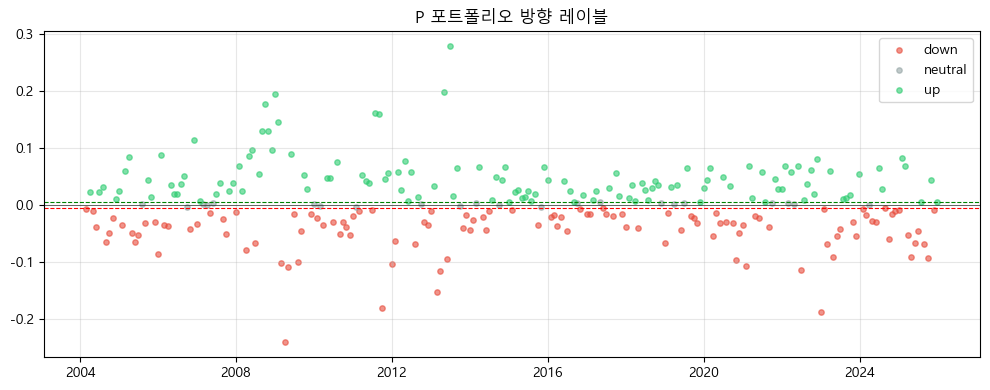

In [11]:
# ── 방향 레이블 생성 ─────────────────────────────────────────
# up     : P_ret[t] > +DIR_THR  → 저위험이 고위험을 유의하게 아웃퍼폼
# down   : P_ret[t] < -DIR_THR  → 고위험이 저위험을 유의하게 아웃퍼폼
# neutral: 그 사이

direction = pd.cut(
    p_ret,
    bins=[-np.inf, -DIR_THR, DIR_THR, np.inf],
    labels=['down', 'neutral', 'up']
)

counts = direction.value_counts()
total  = len(direction.dropna())
print(f'방향 레이블 분포 (DIR_THR=±{DIR_THR*100:.1f}%):')
for cls in ['up', 'neutral', 'down']:
    n = int(counts.get(cls, 0))
    print(f'  {cls:>7}: {n:3d}개  ({n/total:.1%})')

print()
print('[해석]')
print(f'  up+down 비율: {(int(counts.get("up",0))+int(counts.get("down",0)))/total:.1%}  '
      f'(너무 낮으면 DIR_THR 축소 검토)')
print(f'  neutral 비율: {int(counts.get("neutral",0))/total:.1%}  '
      f'(너무 높으면 DIR_THR 축소 검토)')

# 방향별 P_ret 분포
fig, ax = plt.subplots(figsize=(10, 4))
colors_map = {'up': '#2ecc71', 'neutral': '#95a5a6', 'down': '#e74c3c'}
for cls in ['down', 'neutral', 'up']:
    mask = (direction == cls)
    ax.scatter(p_ret[mask].index, p_ret[mask].values,
               color=colors_map[cls], alpha=0.6, s=15, label=cls)
ax.axhline( DIR_THR, color='green', ls='--', lw=0.8)
ax.axhline(-DIR_THR, color='red',   ls='--', lw=0.8)
ax.axhline(0, color='k', lw=0.4)
ax.set_title('P 포트폴리오 방향 레이블')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'direction_labels.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
STOCK_FEATS = [f for f in STOCK_FEATS if f in panel.columns]
MACRO_FEATS = [f for f in MACRO_FEATS if f in panel.columns]

def cs_rank_norm(group, cols):
    out = group.copy()
    for c in cols:
        if c not in out.columns:
            continue
        s = out[c]; valid = s.notna(); n = valid.sum()
        if n < 2:
            continue
        ranked = s[valid].rank(method='average')
        out.loc[valid, c] = 2 * (ranked - 1) / (n - 1) - 1
    return out

def rolling_zscore(s, window=36, min_periods=12):
    mu  = s.rolling(window, min_periods=min_periods).mean()
    sig = s.rolling(window, min_periods=min_periods).std()
    return (s - mu) / sig.replace(0, float('nan'))

print('횡단면 rank 정규화 중...')
panel_norm = (
    panel
    .groupby(panel.index, group_keys=False)
    .apply(lambda g: cs_rank_norm(g, STOCK_FEATS))
)

macro_ts = panel[~panel.index.duplicated(keep='first')][MACRO_FEATS].sort_index()
macro_z  = macro_ts.apply(rolling_zscore).add_prefix('m_')
panel_norm = panel_norm.join(macro_z)

# 횡단면 30/40/30: 날짜별로 하위30%=down(0), 중간40%=neutral(1), 상위30%=up(2)
def cs_label(group):
    r  = group['fwd_excess_ret_1m']
    lo = r.quantile(PCT_GROUP)
    hi = r.quantile(1 - PCT_GROUP)
    lbl = pd.Series(1, index=group.index)
    lbl[r <= lo] = 0
    lbl[r >= hi] = 2
    return lbl

panel_norm['stock_label'] = (
    panel_norm.groupby(panel_norm.index, group_keys=False).apply(cs_label)
)

ALL_FEATS = STOCK_FEATS + [c for c in panel_norm.columns if c.startswith('m_')]

print(f'정규화 완료: {panel_norm.shape}')
print(f'주식 피처: {len(STOCK_FEATS)}개  |  매크로: {len([c for c in ALL_FEATS if c.startswith("m_")])}개')
lbl = panel_norm['stock_label'].value_counts().sort_index()
total_lbl = lbl.sum()
print('레이블 분포 (횡단면 30/40/30):')
for k, n in lbl.items():
    name = {0: 'down', 1: 'neutral', 2: 'up'}.get(int(k), k)
    print(f'  {name:>7}: {n:,}개 ({n/total_lbl:.1%})')

횡단면 rank 정규화 중...
정규화 완료: (108180, 88)
주식 피처: 44개  |  매크로: 18개
레이블 분포 (횡단면 30/40/30):
     down: 32,518개 (30.1%)
  neutral: 43,144개 (39.9%)
       up: 32,518개 (30.1%)


In [13]:
GAP_DAYS    = 21
N_TRIALS    = 20
TRAIN_START = '2004-01-01'

all_dates = sorted(panel_norm.index.unique())
all_dates = [d for d in all_dates if d >= pd.Timestamp(TRAIN_START)]

folds = []
for yr in sorted(set(d.year for d in all_dates)):
    if yr < int(START_PRED):
        continue
    test_start   = pd.Timestamp(f'{yr}-01-01')
    test_end     = pd.Timestamp(f'{yr}-12-31')
    val_start    = pd.Timestamp(f'{yr-1}-01-01')
    val_end      = pd.Timestamp(f'{yr-1}-12-31')
    train_cutoff = val_start - pd.Timedelta(days=GAP_DAYS)
    train_dates  = [d for d in all_dates if d < train_cutoff]
    val_dates    = [d for d in all_dates if val_start <= d <= val_end]
    test_dates   = [d for d in all_dates if test_start <= d <= test_end]
    if len(train_dates) < MIN_TRAIN_YR * 12 or not val_dates or not test_dates:
        continue
    folds.append({'year': yr, 'train': train_dates, 'val': val_dates, 'test': test_dates})

print(f'Walk-forward fold: {len(folds)}개')
for fo in folds:
    print(f"  {fo['year']}: train {min(fo['train']).strftime('%Y-%m')}~"
          f"{max(fo['train']).strftime('%Y-%m')}  "
          f"val {min(fo['val']).strftime('%Y-%m')}~{max(fo['val']).strftime('%Y-%m')}  "
          f"test {len(fo['test'])}개")

def make_objective(X_tr, y_tr, X_val, y_val, seed):
    def objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators', 50, 400),
            max_depth        = trial.suggest_int('max_depth', 2, 6),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.8),
            min_child_weight = trial.suggest_int('min_child_weight', 5, 50),
            reg_lambda=1.0, reg_alpha=0.1,
            objective='multi:softprob', num_class=3,
            tree_method='hist', random_state=seed, n_jobs=-1, verbosity=0,
            eval_metric='mlogloss',
        )
        clf = XGBClassifier(**params)
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        return clf.evals_result()['validation_0']['mlogloss'][-1]
    return objective

oos_records  = []
feat_imp_sum = pd.Series(0.0, index=ALL_FEATS)

for fold in folds:
    yr = fold['year']
    tr = panel_norm[panel_norm.index.isin(fold['train'])].dropna(subset=['stock_label'] + ALL_FEATS[:3])
    va = panel_norm[panel_norm.index.isin(fold['val'])].dropna(subset=['stock_label'] + ALL_FEATS[:3])

    if len(tr) < 300 or len(va) < 50:
        print(f'  {yr}: 데이터 부족 → 스킵')
        continue

    X_tr_arr, y_tr_arr = tr[ALL_FEATS].fillna(0).values, tr['stock_label'].astype(int).values
    X_val_arr, y_val_arr = va[ALL_FEATS].fillna(0).values, va['stock_label'].astype(int).values

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(make_objective(X_tr_arr, y_tr_arr, X_val_arr, y_val_arr, RANDOM_SEED),
                   n_trials=N_TRIALS, show_progress_bar=False)
    bp = study.best_params

    # train+val 합쳐 재학습
    X_tv = np.vstack([X_tr_arr, X_val_arr])
    y_tv = np.concatenate([y_tr_arr, y_val_arr])
    clf  = XGBClassifier(**bp, objective='multi:softprob', num_class=3,
                         tree_method='hist', random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
    clf.fit(X_tv, y_tv)
    feat_imp_sum += pd.Series(clf.feature_importances_, index=ALL_FEATS)

    # 훈련 기간 P_ret 통계 (스케일 계산용)
    p_tr = p_ret[p_ret.index.year < yr].dropna()
    scale = float(p_tr.abs().mean())   # mean |P_ret| → Q 단위 환산
    p_hist_mean = float(p_tr.mean())

    test_months = sorted(panel_norm[panel_norm.index.isin(fold['test'])].index.unique())
    for pred_date in test_months:
        test_month = panel_norm[panel_norm.index == pred_date].copy().reset_index(drop=True)
        if len(test_month) < 10:
            continue

        proba = clf.predict_proba(test_month[ALL_FEATS].fillna(0))  # (N, 3): [down, neutral, up]

        # P 가중치 구성 (vol_21d 기준)
        grp_c  = test_month.dropna(subset=['vol_21d', 'log_mcap']).copy()
        n_g    = max(1, int(len(grp_c) * PCT_GROUP))
        sv     = grp_c['vol_21d'].sort_values()
        lo_idx = sv.index[:n_g]
        hi_idx = sv.index[-n_g:]
        cap_lo = np.exp(grp_c.loc[lo_idx, 'log_mcap'])
        cap_hi = np.exp(grp_c.loc[hi_idx, 'log_mcap'])
        p_w = np.zeros(len(test_month))
        p_w[lo_idx] =  (cap_lo / cap_lo.sum()).values
        p_w[hi_idx] = -(cap_hi / cap_hi.sum()).values

        # r̂_i = prob_up_i - prob_down_i  (논문의 FF3 → r̂ 대체)
        r_hat = proba[:, 2] - proba[:, 0]   # ∈ [-1, 1]

        # Q = P @ r̂  (논문 수식: q = P·r̂)
        Q_raw    = float(p_w @ r_hat)        # 무단위 신호
        Q_ml     = Q_raw * scale             # return 단위로 환산

        actual_p_ret = float(p_ret.get(pred_date, float('nan')))
        oos_records.append({
            'date'        : pred_date,
            'Q_ml'        : Q_ml,
            'Q_raw'       : Q_raw,
            'Q_hist'      : p_hist_mean,
            'actual_p_ret': actual_p_ret,
        })

    print(f"  {yr}: {len(test_months)}개월  val_loss={study.best_value:.4f}  "
          f"lr={bp['learning_rate']:.3f}  depth={bp['max_depth']}  trees={bp['n_estimators']}")

oos_df = pd.DataFrame(oos_records).set_index('date')
print(f'\n완료: {len(oos_df)}개월')
print(f'Q_ml 평균: {oos_df["Q_ml"].mean():+.5f}  std: {oos_df["Q_ml"].std():.5f}')
print(f'Q_hist 평균: {oos_df["Q_hist"].mean():+.5f}')
print(f'Q_FIXED 기존: +0.00300')

Walk-forward fold: 17개
  2009: train 2004-01~2007-11  val 2008-01~2008-12  test 12개
  2010: train 2004-01~2008-11  val 2009-01~2009-12  test 12개
  2011: train 2004-01~2009-11  val 2010-01~2010-12  test 12개
  2012: train 2004-01~2010-11  val 2011-01~2011-12  test 12개
  2013: train 2004-01~2011-11  val 2012-01~2012-12  test 12개
  2014: train 2004-01~2012-11  val 2013-01~2013-12  test 12개
  2015: train 2004-01~2013-11  val 2014-01~2014-12  test 12개
  2016: train 2004-01~2014-11  val 2015-01~2015-12  test 12개
  2017: train 2004-01~2015-11  val 2016-01~2016-12  test 12개
  2018: train 2004-01~2016-11  val 2017-01~2017-12  test 12개
  2019: train 2004-01~2017-11  val 2018-01~2018-12  test 12개
  2020: train 2004-01~2018-11  val 2019-01~2019-12  test 12개
  2021: train 2004-01~2019-11  val 2020-01~2020-12  test 12개
  2022: train 2004-01~2020-11  val 2021-01~2021-12  test 12개
  2023: train 2004-01~2021-11  val 2022-01~2022-12  test 12개
  2024: train 2004-01~2022-11  val 2023-01~2023-12  test 12개
 

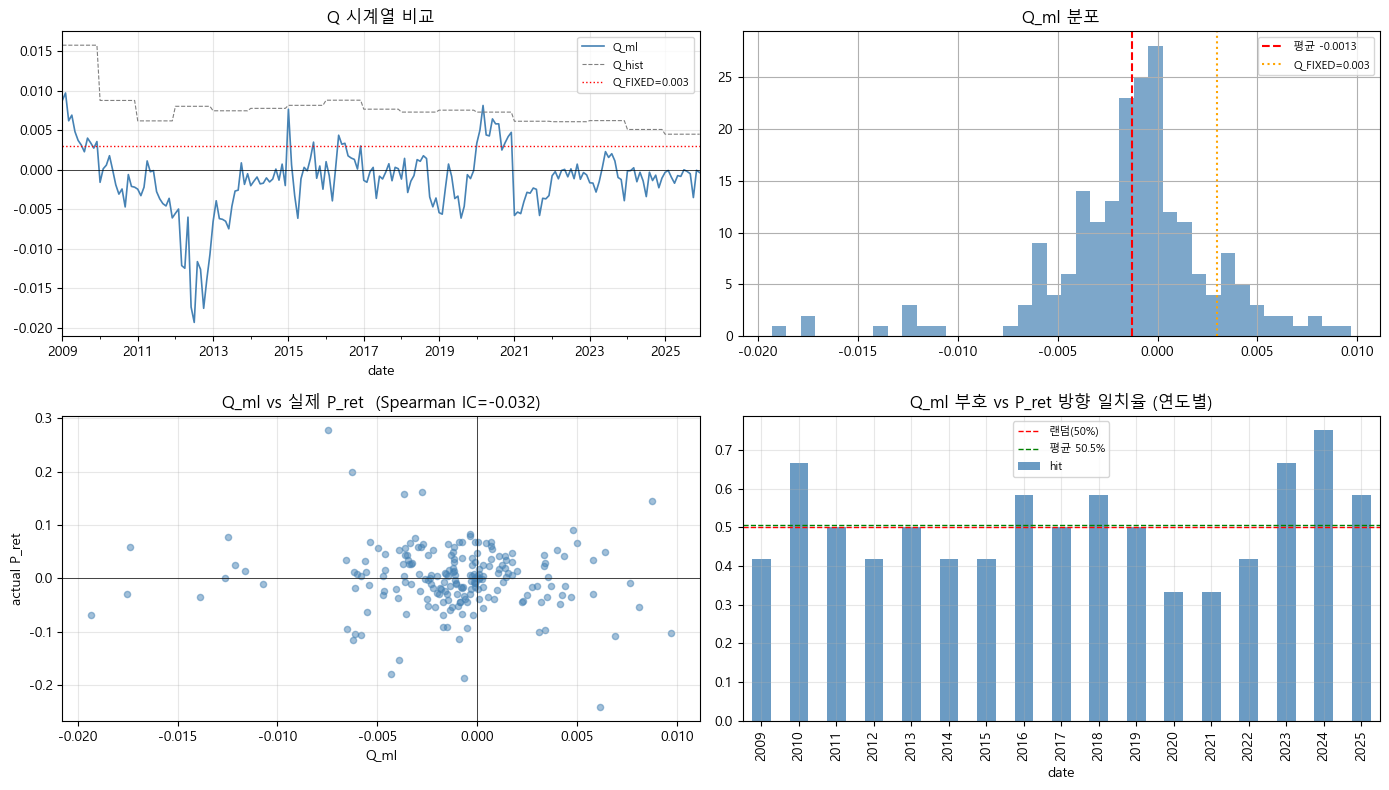

=== Q_ml 요약 ===
평균 Q_ml   : -0.00128  (연 -1.53%)
std Q_ml    : 0.00418
Q_ml > 0    : 32.4%
Q_hist 평균 : +0.00755
Q_FIXED 기존: +0.00300

Spearman IC (Q_ml vs P_ret): -0.032
방향 일치율: 50.5%  (랜덤=50%)


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Q_ml 시계열
oos_df['Q_ml'].plot(ax=axes[0,0], color='steelblue', lw=1.2, label='Q_ml')
oos_df['Q_hist'].plot(ax=axes[0,0], color='gray', lw=0.8, ls='--', label='Q_hist')
axes[0,0].axhline(0.003, color='red', ls=':', lw=1, label='Q_FIXED=0.003')
axes[0,0].axhline(0, color='k', lw=0.5)
axes[0,0].set_title('Q 시계열 비교')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Q_ml 분포
oos_df['Q_ml'].hist(bins=40, ax=axes[0,1], color='steelblue', alpha=0.7)
axes[0,1].axvline(oos_df['Q_ml'].mean(), color='red', ls='--', label=f"평균 {oos_df['Q_ml'].mean():+.4f}")
axes[0,1].axvline(0.003, color='orange', ls=':', label='Q_FIXED=0.003')
axes[0,1].set_title('Q_ml 분포')
axes[0,1].legend(fontsize=8)

# Q_ml vs 실제 P_ret 산점도
valid = oos_df.dropna(subset=['Q_ml', 'actual_p_ret'])
axes[1,0].scatter(valid['Q_ml'], valid['actual_p_ret'], alpha=0.5, s=20, color='steelblue')
axes[1,0].axhline(0, color='k', lw=0.5)
axes[1,0].axvline(0, color='k', lw=0.5)
ic = valid['Q_ml'].corr(valid['actual_p_ret'], method='spearman')
axes[1,0].set_title(f'Q_ml vs 실제 P_ret  (Spearman IC={ic:+.3f})')
axes[1,0].set_xlabel('Q_ml')
axes[1,0].set_ylabel('actual P_ret')
axes[1,0].grid(True, alpha=0.3)

# Q_ml 부호 vs 실제 P_ret 방향 일치율
valid['q_up'] = valid['Q_ml'] > 0
valid['p_up'] = valid['actual_p_ret'] > 0
valid['hit']  = valid['q_up'] == valid['p_up']
hit_yr = valid.groupby(valid.index.year)['hit'].mean()
hit_yr.plot(kind='bar', ax=axes[1,1], color='steelblue', alpha=0.8)
axes[1,1].axhline(0.5, color='red', ls='--', lw=1, label='랜덤(50%)')
axes[1,1].axhline(valid['hit'].mean(), color='green', ls='--', lw=1,
                  label=f"평균 {valid['hit'].mean():.1%}")
axes[1,1].set_title('Q_ml 부호 vs P_ret 방향 일치율 (연도별)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_q_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Q_ml 요약 ===')
print(f'평균 Q_ml   : {oos_df["Q_ml"].mean():+.5f}  (연 {oos_df["Q_ml"].mean()*12*100:.2f}%)')
print(f'std Q_ml    : {oos_df["Q_ml"].std():.5f}')
print(f'Q_ml > 0    : {(oos_df["Q_ml"] > 0).mean():.1%}')
print(f'Q_hist 평균 : {oos_df["Q_hist"].mean():+.5f}')
print(f'Q_FIXED 기존: +0.00300')
print(f'\nSpearman IC (Q_ml vs P_ret): {ic:+.3f}')
print(f'방향 일치율: {valid["hit"].mean():.1%}  (랜덤=50%)')

In [17]:
oos_df[['Q_ml', 'Q_raw', 'Q_hist', 'actual_p_ret']].to_csv(OUTPUT_DIR / 'ml_q_predictions.csv')

print('저장 완료:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

print()
print('=' * 55)
print('99_baseline.ipynb 연동 방법')
print('=' * 55)
print('''
ml_q = pd.read_csv('outputs/05_ml_q/ml_q_predictions.csv',
                   index_col='date', parse_dates=True)

# walk-forward 루프 내 Q 대체
if pred_date in ml_q.index:
    q = float(ml_q.loc[pred_date, 'Q_ml'])
else:
    q = Q_FIXED   # fallback
''')

저장 완료:
  direction_labels.png
  eda_annual_dist.png
  eda_confusion_matrix.png
  ml_q_evaluation.png
  ml_q_predictions.csv
  p_ret_series.png

99_baseline.ipynb 연동 방법

ml_q = pd.read_csv('outputs/05_ml_q/ml_q_predictions.csv',
                   index_col='date', parse_dates=True)

# walk-forward 루프 내 Q 대체
if pred_date in ml_q.index:
    q = float(ml_q.loc[pred_date, 'Q_ml'])
else:
    q = Q_FIXED   # fallback

